In [21]:
from google.colab import files
import pandas as pd
uploaded = files.upload()
uploaded = files.upload()
# Load data
X1 = pd.read_csv("X1_new.csv", header=None).values
X2 = pd.read_csv("X2_new.csv", header=None).values

Saving X1_new.csv to X1_new (1).csv


Saving X2_new.csv to X2_new (1).csv


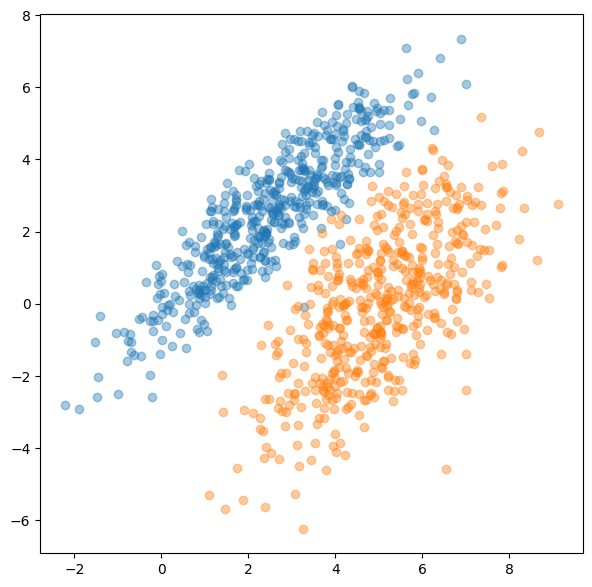

In [22]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(X1[:,0], X1[:,1], alpha=0.4, label="Class 1")
ax.scatter(X2[:,0], X2[:,1], alpha=0.4, label="Class 2")

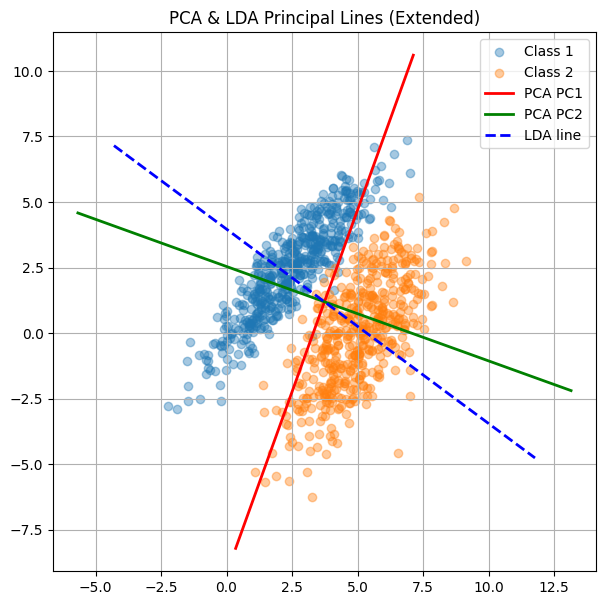

In [23]:
import numpy as np

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA





# Labels
y1 = np.zeros(X1.shape[0])
y2 = np.ones(X2.shape[0])
X = np.vstack([X1, X2])
y = np.hstack([y1, y2])

# PCA
pca = PCA(n_components=2).fit(X)
pc1, pc2 = pca.components_

# LDA
lda = LDA(n_components=1).fit(X, y)
lda_dir = lda.coef_[0] / np.linalg.norm(lda.coef_[0])

# Function to extend a line through mean in given direction
def extended_line(ax, mean, direction, style, label):
    direction = direction / np.linalg.norm(direction)
    xlims = ax.get_xlim()
    ylims = ax.get_ylim()

    # generate two far points along the direction
    pts = np.array([
        mean - 10*direction,
        mean + 10*direction
    ])
    ax.plot(pts[:,0], pts[:,1], style, lw=2, label=label)

# Plot
fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(X1[:,0], X1[:,1], alpha=0.4, label="Class 1")
ax.scatter(X2[:,0], X2[:,1], alpha=0.4, label="Class 2")

mean = np.mean(X, axis=0)

# Draw extended lines
extended_line(ax, mean, pc1, 'r-', "PCA PC1")
extended_line(ax, mean, pc2, 'g-', "PCA PC2")
extended_line(ax, mean, lda_dir, 'b--', "LDA line")

ax.axis('equal')
ax.grid(True)
ax.legend()
ax.set_title("PCA & LDA Principal Lines (Extended)")
plt.show()
